# `=== Atelier Matplotlib ===`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### `Importation du dataset mesures_capteurs.csv`

In [2]:
# le dataset mesures_capteurs.csv contient les données pré-traité lors de l'atelier pandas
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite_relative,pression,consommation,etat,nouveau_temperature
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK,Normal
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK,Normal
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK,Normal
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK,Normal
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK,Normal


## `Partie 1 – Graphique linéaire (Line Plot)`

#### `1.1 Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.`

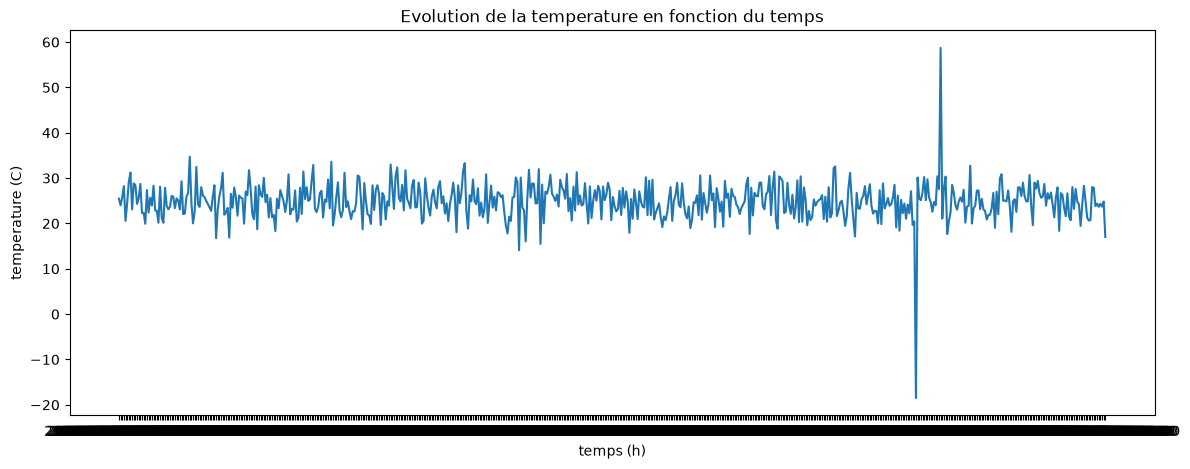

In [17]:
# Pré-traitement du dataset
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(df['date_heure'], df["temperature"])
ax.set_xlabel("temps (h)")
ax.set_ylabel("temperature (C)")
ax.set_title("Evolution de la temperature en fonction du temps")
plt.show()

### `Les valeurs anormales: visuelement`

In [20]:
print(f" visuelement les valeurs qui s'emble anormales sont: le min = {df['temperature'].min()} et le max: {df['temperature'].max()}")

 visuelement les valeurs qui s'emble anormales sont: le min = -18.5 et le max: 58.7


## `Partie 2 – Diagramme en barres (Bar Chart)`

#### `2.1 On determine consommation_batiment qui stocke les consommations moyennes des bâtiments`

In [9]:
consommation_batiment = df.groupby('batiment')["consommation"].mean()
consommation_batiment 

batiment
B001    178.499267
B002    221.785333
B003    153.191000
B004    281.212800
Name: consommation, dtype: float64

#### `2.2 Comparaison graphique de la consommation moyenne des bâtiments`

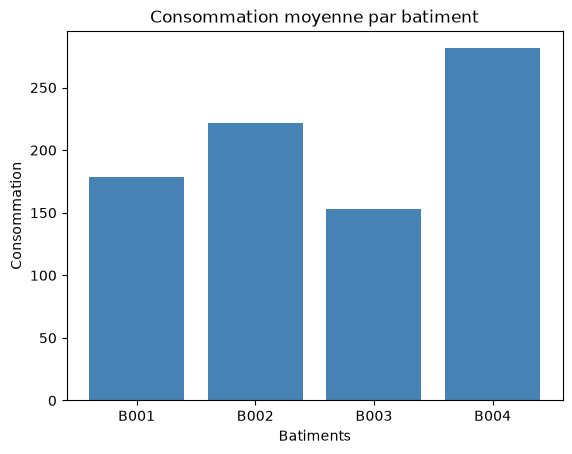

In [18]:
fig, ax = plt.subplots()

plt.bar(consommation_batiment.index, consommation_batiment.values, color="steelblue")
ax.set_xlabel("Batiments")
ax.set_ylabel("Consommation")
ax.set_title("Consommation moyenne par batiment")
plt.show()

#### `2.3 Comparaison de la consommation moyenne des bâtiments avec un graphique horizontal`

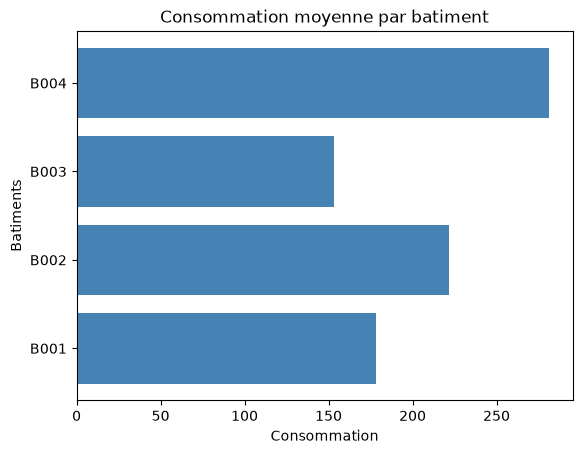

In [21]:
fig, ax = plt.subplots()

plt.barh(consommation_batiment.index, consommation_batiment.values, color="steelblue")
ax.set_xlabel("Consommation")
ax.set_ylabel("Batiments")
ax.set_title("Consommation moyenne par batiment")
plt.show()

#### `2.4 Dans quels cas un graphique horizontal peut-il être plus lisible ?`

- `Noms long`: lorsque les etiquêttes contiennent beaucoup de caractère, le format horizontal évite qu'elles ne se supperposent ou soient coupés
- `Grand nombre de catégories`: S'il y a plus de 6 ou 7 éléments à comparer, les barres verticales deviennent trop fines et serrées, alors qu'un affichage horizontal laisse de l'espace pour dérouler la liste de haut en bas
- `...`

## `Partie 3 – Histogramme`

##### `3.1 Affichage de la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille`

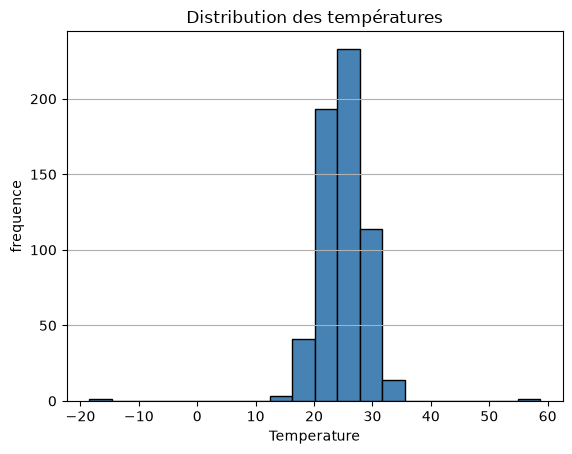

In [33]:
plt.hist(df["temperature"], bins=20, color="steelblue", edgecolor="black")
plt.grid(axis='y')
plt.xlabel("Temperature")
plt.ylabel("frequence")
plt.title("Distribution des températures")
plt.show()

#### `3.2 Analyse du graphique`

`- a`: Les températures se concentrent sur l'intervalle: 20 à 30

`- b: Vérification de la symétrie `

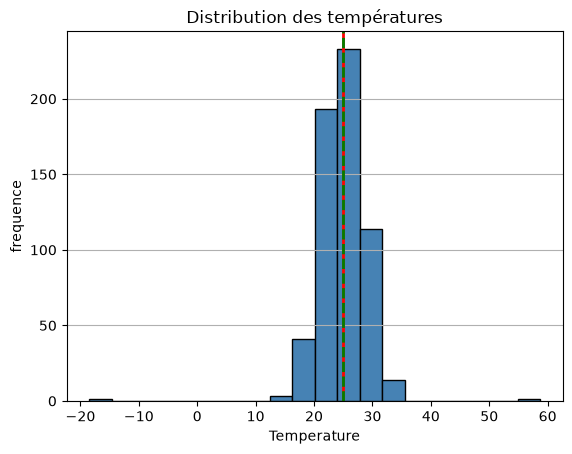

In [31]:
plt.hist(df["temperature"], bins=20, color="steelblue", edgecolor="black")
plt.grid(axis='y')
 # Ajout des lignes de repère pour vérifier la symétrie (trait en rouge et en vert)
plt.axvline(df["temperature"].mean(), color='red', linestyle='-', linewidth=2, label=f'Moyenne ({df["temperature"].mean():.2f})')
plt.axvline(df["temperature"].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane ({df["temperature"].median():.2f})')

plt.xlabel("Temperature")
plt.ylabel("frequence")
plt.title("Distribution des températures")
plt.show()

Graphiquement on peut observer que les traits representant respectivement le moyennne et la mediane

`- c :`

Graphiquement on peut observer la grande différence entre les differents intervalles

`- d :`

Dans ce graphe les valeurs des températures sont regroupées par classe, donc on peut pas voir avec precision les valeurs abérantes

#### `3.3 Affichage de la distribution de la consommation en divisant la plage des données en 20 classes`

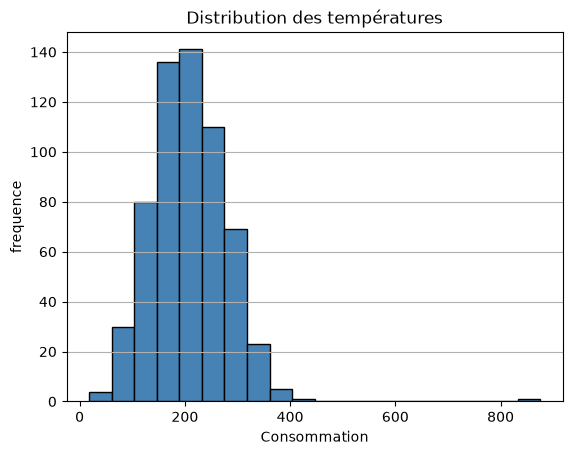

In [34]:
plt.hist(df["consommation"], bins=20, color="steelblue", edgecolor="black")
plt.grid(axis='y')
plt.xlabel("Consommation")
plt.ylabel("frequence")
plt.title("Distribution des températures")
plt.show()

`- a: Modification avec le nombre de classes à 10`

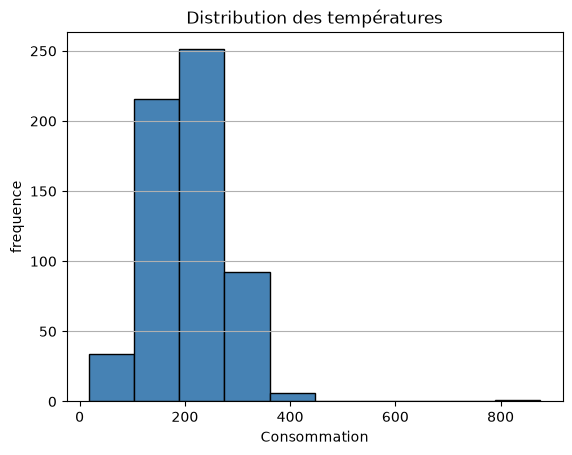

In [35]:
plt.hist(df["consommation"], bins=10, color="steelblue", edgecolor="black")
plt.grid(axis='y')
plt.xlabel("Consommation")
plt.ylabel("frequence")
plt.title("Distribution des températures")
plt.show()

`- b: Modification avec le nombre de classe à 30`

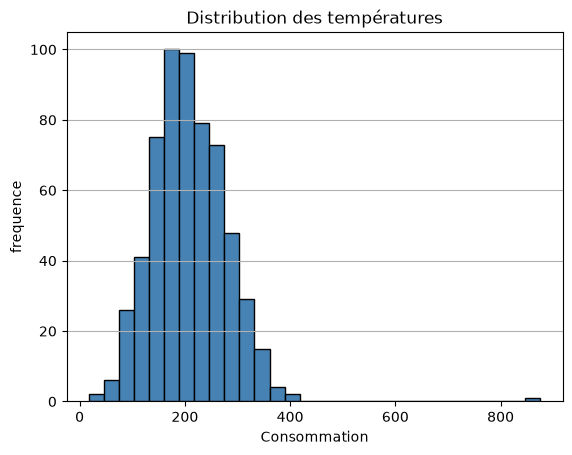

In [37]:
plt.hist(df["consommation"], bins=30, color="steelblue", edgecolor="black")
plt.grid(axis='y')
plt.xlabel("Consommation")
plt.ylabel("frequence")
plt.title("Distribution des températures")
plt.show()

`- c:`

Le nombre de classes influence directement l'interprétation :

- Peu de classes → distribution trop lissée, on perd des détails importants
- Trop de classes → on voit du bruit statistique, pas forcément de vraies tendances
- Nombre intermédiaire → meilleur compromis entre lisibilité et fidélité aux données

En résumé : changer le nombre de bins ne change pas les données, mais peut faire dire des choses différentes sur la même distribution. Il faut donc tester plusieurs valeurs avant de conclure.

## `Partie 4 – Nuage de points (Scatter Plot)`
 

#### `4.1 Nuage de points entre température et consommation`

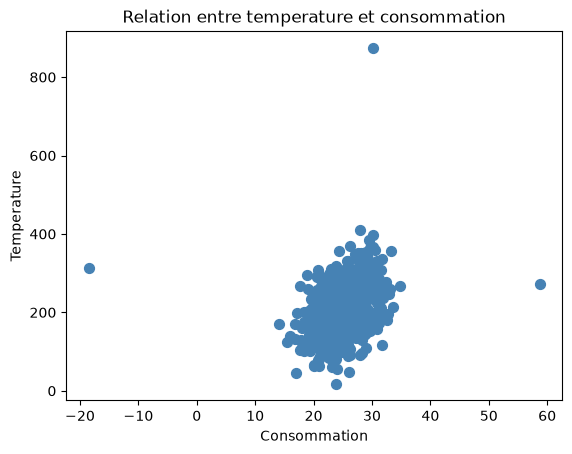

In [39]:
plt.scatter(df["temperature"], df["consommation"], color="steelblue", s=50)
plt.title("Relation entre temperature et consommation")
plt.xlabel("Consommation")
plt.ylabel("Temperature")
plt.show()

#### `4.2 On détermine visuellement s'il semble exister une relation entre les deux`

Visuellement il ne semble pas y avoir de relation évidente entre les deux variables — le nuage a plutôt une forme de "blob" central sans direction. Pour confirmer ça de façon quantitative, on peux calculer le coefficient de corrélation :

In [41]:
correlation = df['consommation'].corr(df['temperature'])
print(f"Coefficient de corrélation : {correlation:.3f}")

Coefficient de corrélation : 0.319


### `Partie 4 – Nuage de points (Scatter Plot)`

#### `4.1 Création d'un box plot de la température.`

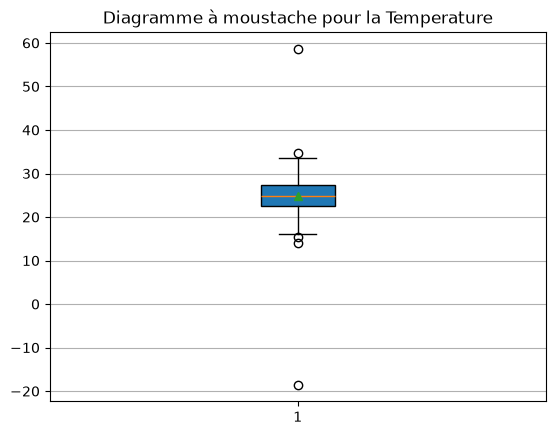

In [52]:
plt.boxplot(df['temperature'], showmeans=True, patch_artist=True)
plt.grid(axis='y')
plt.title("Diagramme à moustache pour la Temperature")
plt.show()

#### `4.2 Que représentent les points situés en dehors des moustaches ?`

les points situés en déhors des moustaches representent les outliers, les valeurs abérentes.

#### `4.3 Créer un box plot de la consommation`

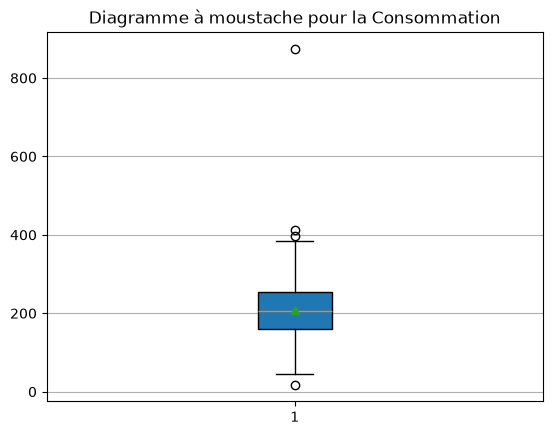

In [53]:
plt.boxplot(df['consommation'], showmeans=True, patch_artist=True)
plt.grid(axis='y')
plt.title("Diagramme à moustache pour la Consommation")
plt.show()

#### `4.4 A partir des deux box plot, comparer :`

`- a: la position de la médiane:`

`Consommation` : médiane autour de ~200
`Température` : médiane autour de ~24

`- b: la taille de la boîte:`

`Consommation` : boîte assez large, entre ~170 et ~250 (IQR ≈ 80)
`Température` : boîte plus étroite, entre ~22 et ~27 (IQR ≈ 5)

`- c: la longueur des moustaches: `

`Consommation` : moustaches assez longues, de ~20 à ~380
`Température` : moustaches courtes, de ~14 à ~34


`- d: les valeurs extrêmes:`

`Consommation` : un outlier marqué autour de 870, quelques-uns proches de 400 et un vers 20
`Température` : deux outliers nets, un très haut (~59) et un très bas (~19)

#### `4.5 La consommation présente-t-elle davantage de dispersion que la température ?`


Oui, la consommation présente davantage de dispersion que la température :

Son IQR est beaucoup plus grand (~80 contre ~5)
Ses moustaches couvrent une plage bien plus large (~20 à 380, contre ~14 à 34)
Même si les deux variables ont des outliers, l'échelle globale de variation de la consommation est nettement supérieure à celle de la température.

## `Partie 6 – Diagramme circulaire (Pie Chart)`

#### `6.1 Réaliser un diagramme pour analyser la répartition des états (OK, ALERTE, ERREUR)`

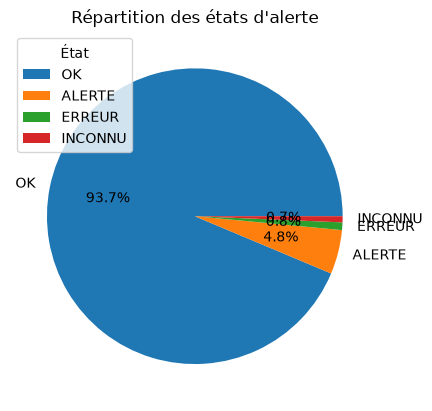

In [101]:
element = df["etat"].value_counts()

label = list(element.index)
size = list(element.values)

plt.pie(size, labels=label, autopct="%1.1f%%")
plt.title("Répartition des états d'alerte")
plt.legend(title="État", loc="best")
plt.show()

#### `6.2 Interprétation de la proportion de capteurs OK ; proportion ALERTE ; proportion ERREUR`

OK (93,7 %) : presque tous les capteurs vont bien.


ALERTE (4,8 %) : une petite partie signale une anomalie à surveiller.


ERREUR (0,8 %) : très peu de capteurs sont en panne, mais c'est à corriger en priorité.

## `Partie 7 : Plusieurs courbes sur un même graphique`

#### `7.1 Évolution de la température par bâtiment" » des quatre bâtiments.`

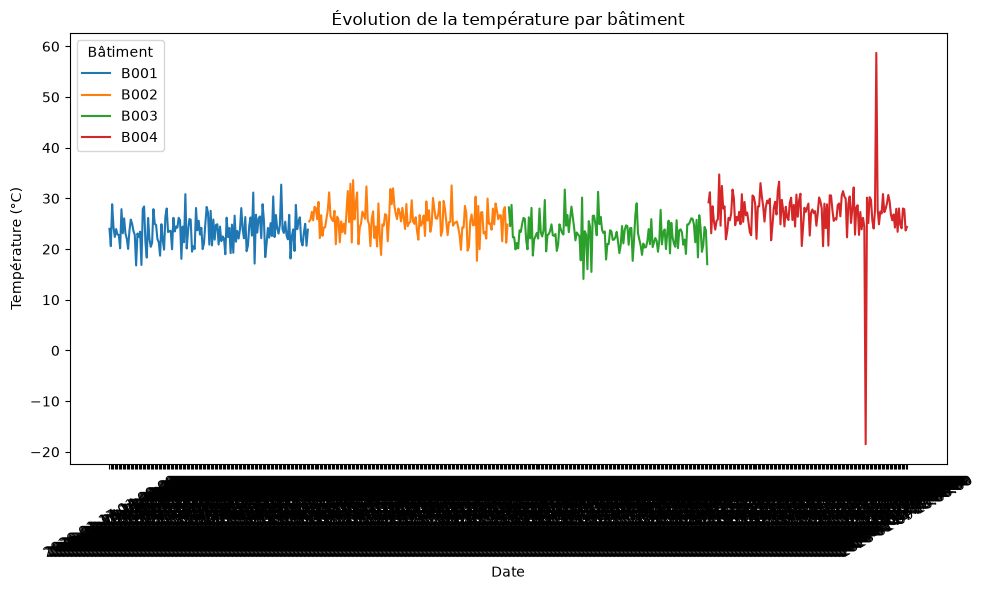

In [ ]:
plt.figure(figsize=(10, 6))

for batiment, groupe in df.groupby("batiment"):
    plt.plot(groupe["date_heure"], groupe["temperature"], label=batiment)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Évolution de la température par bâtiment")
plt.legend(title="Bâtiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## `Partie 8 : Sauvegarde des graphiques`

#### `8.1 Sauvegarder le graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.png`

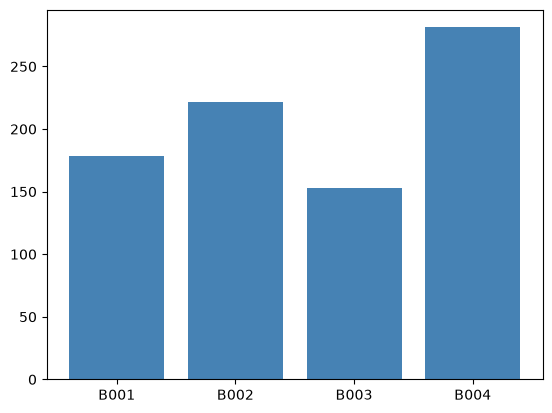

In [102]:
plt.bar(consommation_batiment.index, consommation_batiment.values, color="steelblue")
ax.set_xlabel("Batiments")
ax.set_ylabel("Consommation")
ax.set_title("Consommation moyenne par batiment")

plt.savefig("../exports/temperature.png", dpi=300, bbox_inches="tight")
plt.show()

### `8.2 Sauvegarde du graphique sur l'évolution de la température en fonction du temps dans exports/ temperature.pdf`

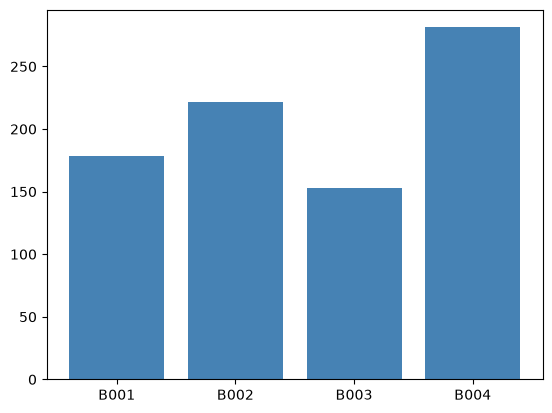

In [103]:
plt.bar(consommation_batiment.index, consommation_batiment.values, color="steelblue")
ax.set_xlabel("Batiments")
ax.set_ylabel("Consommation")
ax.set_title("Consommation moyenne par batiment")

plt.savefig("../exports/temperature.pdf", dpi=300, bbox_inches="tight")
plt.show()

### `Bonus: Heatmap de corrélation entre toutes les variables numériques`

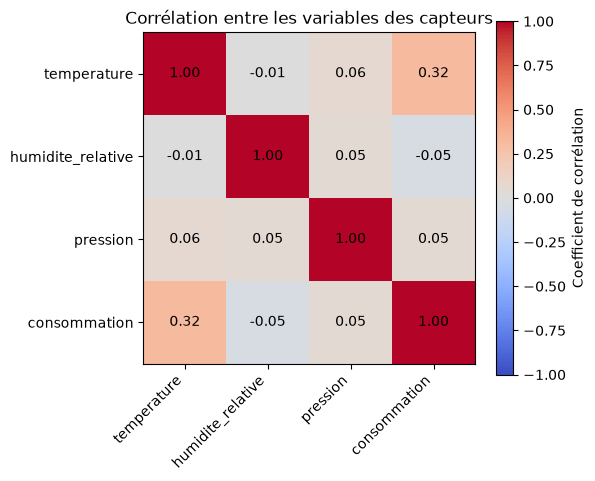

In [128]:
import matplotlib.pyplot as plt

correlation = df[["temperature", "humidite_relative", "pression", "consommation"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, label="Coefficient de corrélation")
plt.title("Corrélation entre les variables des capteurs")
plt.tight_layout()
plt.savefig("../exports/correlation.png")
plt.show()